# Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a statistical technique used to analyze and reduce the dimensionality of data. It identifies the directions (principal components) along which the variance of the data is maximized. PCA is widely used in fields such as machine learning, pattern recognition, and data compression.

## Steps to Calculate PCA

1. **Standardize the Data:**
   Center the data by subtracting the mean of each variable from the data values, so that the dataset has a mean of zero. For a dataset $X$ with $n$ observations and $p$ features:

   $$
   X_{\text{centered}} = X - \text{mean}(X)
   $$

2. **Compute the Covariance Matrix:**
   Calculate the covariance matrix $C$ of the centered data. For a dataset $X$ with $p$ features, the covariance matrix $C$ is given by:

   $$
   C = \frac{1}{n-1} X_{\text{centered}}^T X_{\text{centered}}
   $$

   where $X_{\text{centered}}^T$ is the transpose of the centered data matrix $X_{\text{centered}}$.

3. **Calculate the Eigenvalues and Eigenvectors:**
   Solve the eigenvalue problem for the covariance matrix $C$. The eigenvalue equation is:

   $$
   C v = \lambda v
   $$

   where $v$ is an eigenvector and $\lambda$ is the corresponding eigenvalue.

4. **Sort Eigenvalues and Eigenvectors:**
   Order the eigenvalues in descending order and sort the eigenvectors accordingly. The eigenvectors corresponding to the largest eigenvalues are the principal components.

5. **Form the Principal Components:**
   Construct the principal components matrix $W$ using the top $k$ eigenvectors (where $k$ is the number of desired principal components).

6. **Transform the Data:**
   Project the original data onto the new principal component space:

   $$
   X_{\text{reduced}} = X_{\text{centered}} W
   $$

   Here, $X_{\text{reduced}}$ is the data in the reduced dimensionality space.

## Summary of Formulas

1. **Standardize Data:**

   $$
   X_{\text{centered}} = X - \text{mean}(X)
   $$

2. **Covariance Matrix:**

   $$
   C = \frac{1}{n-1} X_{\text{centered}}^T X_{\text{centered}}
   $$

3. **Eigenvalue Equation:**

   $$
   C v = \lambda v
   $$

4. **Transform Data:**

   $$
   X_{\text{reduced}} = X_{\text{centered}} W
   $$

By following these steps, PCA helps in reducing the number of dimensions of your dataset while retaining most of the variance in the data.


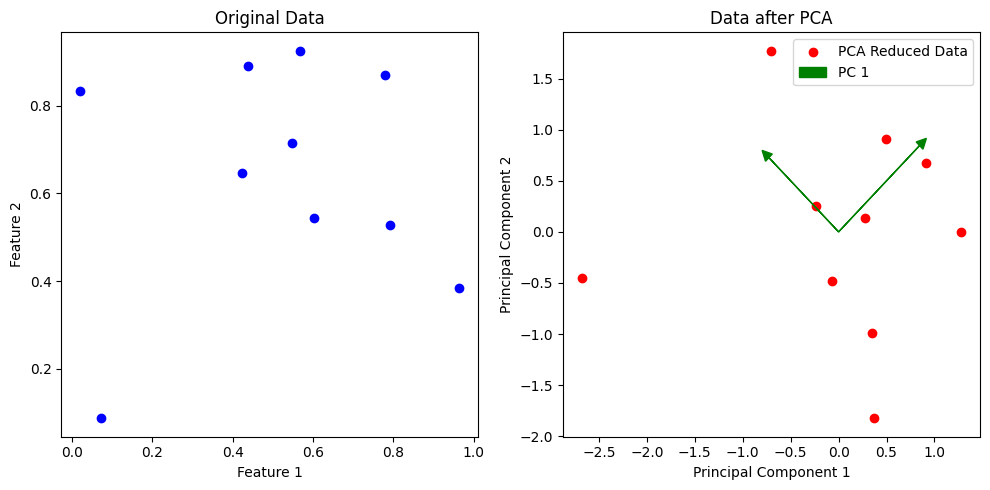

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Generate synthetic data
np.random.seed(0)
X = np.random.rand(10, 2)  # 10 samples, 2 features

# Center the data
scaler = StandardScaler()
X_centered = scaler.fit_transform(X)

# Compute the covariance matrix
cov_matrix = np.cov(X_centered.T)

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort eigenvalues and eigenvectors
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

# Project the data onto the principal components
X_reduced = X_centered.dot(eigenvectors)

# Plot the original data
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], color='blue', label='Original Data')
plt.title('Original Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

# Plot the data with principal components
plt.subplot(1, 2, 2)
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], color='red', label='PCA Reduced Data')
plt.title('Data after PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# Plot the principal components
for i in range(len(eigenvectors)):
    plt.arrow(0, 0, eigenvectors[0, i] * eigenvalues[i], eigenvectors[1, i] * eigenvalues[i],
              head_width=0.1, head_length=0.1, fc='green', ec='green', label=f'PC {i+1}' if i == 0 else "")

plt.legend()
plt.tight_layout()
plt.show()


# Detailed Code

First eigenvalue: 0.0921770008838929
First eigenvector: [0.96412478 0.26544944]
Second eigenvalue: 0.06873322541570914
Second eigenvector: [-0.26544944  0.96412478]


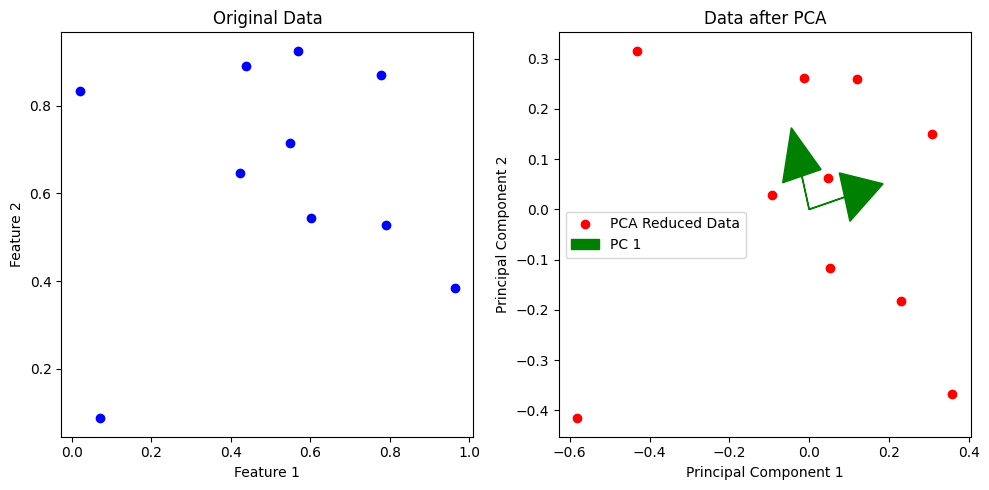

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def power_iteration(A, num_iterations: int):
    # Initialize a random vector
    b_k = np.random.rand(A.shape[1])
    for _ in range(num_iterations):
        # Calculate the matrix-by-vector product Ab
        b_k1 = np.dot(A, b_k)
        # Update b_k to the normalized version of b_k1
        b_k = b_k1 / np.linalg.norm(b_k1)
    # The eigenvalue is approximated by the Rayleigh quotient
    eigenvalue = np.dot(b_k.T, np.dot(A, b_k))
    return eigenvalue, b_k

def deflation(A, eigenvalue, eigenvector):
    # Deflate the matrix A using the found eigenvalue and eigenvector
    return A - eigenvalue * np.outer(eigenvector, eigenvector)

# Generate synthetic data
np.random.seed(0)
X = np.random.rand(10, 2)  # 10 samples, 2 features

# Standardize the data (mean=0, variance=1)
mean = np.mean(X, axis=0)
X_centered = X - mean

# Compute the covariance matrix
cov_matrix = np.dot(X_centered.T, X_centered) / (X_centered.shape[0] - 1)

# Compute the first principal component
eigenvalue, eigenvector = power_iteration(cov_matrix, num_iterations=100)
print(f"First eigenvalue: {eigenvalue}")
print(f"First eigenvector: {eigenvector}")

# Compute the second principal component by deflating
cov_matrix_deflated = deflation(cov_matrix, eigenvalue, eigenvector)
eigenvalue2, eigenvector2 = power_iteration(cov_matrix_deflated, num_iterations=100)
print(f"Second eigenvalue: {eigenvalue2}")
print(f"Second eigenvector: {eigenvector2}")

# Form the eigenvalues and eigenvectors matrix
eigenvalues = np.array([eigenvalue, eigenvalue2])
eigenvectors = np.column_stack([eigenvector, eigenvector2])

# Project the data onto the principal components
X_reduced = np.dot(X_centered, eigenvectors)

# Plot the original data
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], color='blue', label='Original Data')
plt.title('Original Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

# Plot the data with principal components
plt.subplot(1, 2, 2)
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], color='red', label='PCA Reduced Data')
plt.title('Data after PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# Plot the principal components
origin = np.mean(X_reduced, axis=0)  # Origin for the arrows
for i in range(eigenvectors.shape[1]):
    plt.arrow(0, 0, eigenvectors[0, i] * eigenvalues[i], eigenvectors[1, i] * eigenvalues[i],
              head_width=0.1, head_length=0.1, fc='green', ec='green', label=f'PC {i+1}' if i == 0 else "")

plt.legend()
plt.tight_layout()
plt.show()


## Explanation

### Power Iteration:
This method approximates the largest eigenvalue and eigenvector. It repeatedly multiplies a random vector by the covariance matrix and normalizes it.

### Deflation:
Removes the influence of the found eigenvalue and eigenvector from the covariance matrix to find the next largest eigenvalue and eigenvector.

### Eigenvalues and Eigenvectors Computation:
Computes the first and second eigenvalues and eigenvectors using the power iteration and deflation methods.

### Projection and Plotting:
Projects the centered data onto the principal components and visualizes both the original and PCA-reduced data.
